In this notebook, we will preprocess the data and apply an Extreme Gradient Boosting model (XGBoost). We will train it on the full dataset.

In [1]:
# Imports
import numpy as np
import pandas as pd

# Plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Classifier
import xgboost as xgb

# Metrics
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, roc_curve, auc

# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import RobustScaler

SEED = 42

In [2]:
df_train = pd.read_csv('..\\data\\train.csv')
y = df_train['IsFraud']
X = df_train.drop(['IsFraud', 'id', 'Time'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y , random_state=SEED)

model = xgb.XGBClassifier(tree_method='gpu_hist',
                        predictor='gpu_predictor',
                        gpu_id=0,
                        n_jobs=1,
                        subsample= 0.5, n_estimators = 400, min_child_weight = 5, max_depth = 3, learning_rate = 0.01, gamma = 0.2, colsample_bytree = 0.7,
                        random_state=SEED)

preprocessor = ColumnTransformer([
    ("robust_scale", RobustScaler(), ['Transaction_Amount']),
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

pipeline.fit(X_train,y_train)

c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:04:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:04:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:04:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, itera

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('robust_scale', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Results


In [3]:
preds = pipeline.predict(X_test)
# Detaiiled precision/recall/F1 by class:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29946
           1       0.00      0.00      0.00        54

    accuracy                           1.00     30000
   macro avg       0.50      0.50      0.50     30000
weighted avg       1.00      1.00      1.00     30000



c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:2676: UserWarning: [08:04:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:729: UserWarning: [08:04:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only b

In [4]:
# 2) ROC AUC for overall separability
probs = pipeline.predict_proba(X_test)[:,1]
print('ROC AUC:', roc_auc_score(y_test, probs))

# 3) Precision-Recall AUC (more informative when positives are rare):
precision, recall, _ = precision_recall_curve(y_test, probs)
print('PR AUC', auc(recall, precision))

ROC AUC: 0.816484486891219
PR AUC 0.03128400987260092


<function matplotlib.pyplot.show(close=None, block=None)>

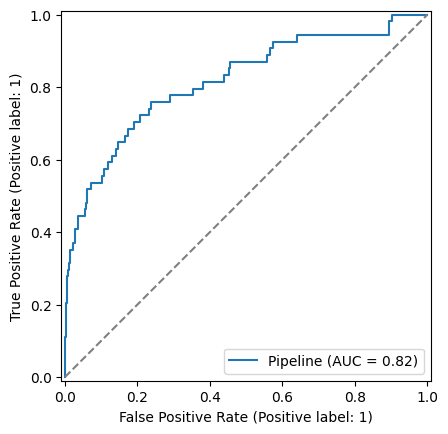

In [5]:
disp = RocCurveDisplay.from_estimator(
    pipeline, X_test, y_test,
    # name=f'ROC (AUC = {roc_auc:.3f})'
)
plt.plot([0,1],[0,1],'--',color='gray')
plt.show

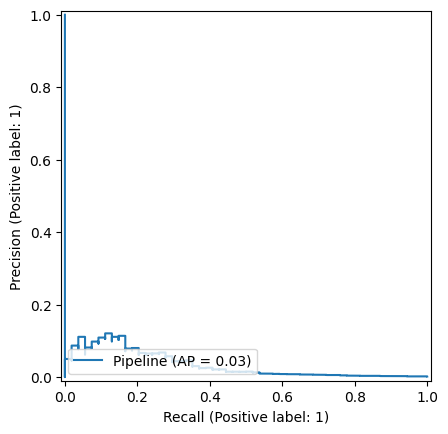

In [6]:
disp2 = PrecisionRecallDisplay.from_estimator(
    pipeline, X_test, y_test,
)
plt.show()

# Submission for Kaggle

We use our model to make predictions based on the test data from the Kaggle competition Credit Card Fraud Detection (the link: https://www.kaggle.com/competitions/credit-card-fraud-prediction/)


In [7]:
test_df = pd.read_csv('../data/test.csv')
submission_data = test_df.drop(['id','Time'], axis=1)
preds_for_submission = pipeline.predict_proba(submission_data) # Get predictions

output = pd.DataFrame(
    {
        'id' : test_df.id,
        'IsFraud' : preds_for_submission[:,1]
    }
)
output.to_csv('submission.csv', index=False)
output.head()

,id,IsFraud
0,150000,0.001093
1,150001,0.001041
2,150002,0.001985
3,150003,0.001657
4,150004,0.002104


We got 0.70823 for the Private Score and 0.77310 for the Public Score.


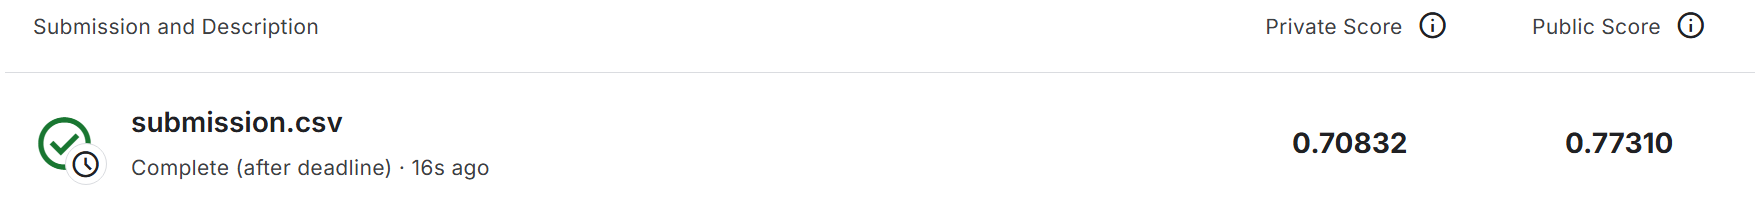


### Exports for MLops project

In [8]:
features = list(submission_data.columns)

In [9]:
import joblib, json, os

In [10]:
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/xgb_model.joblib')

['../models/xgb_model.joblib']

In [11]:
joblib.dump(preprocessor, '../models/xgb_preprocessor.joblib')

['../models/xgb_preprocessor.joblib']

In [12]:
json.dump(features, open('../models/features.json','w'))

In [18]:
features_all = list(df_train.columns)
json.dump(features_all, open('../models/features_all.json','w'))

In [14]:
# tests
# submission_data2 = preprocessor.transform(submission_data)

In [15]:
# test = model.predict_proba(submission_data2)

In [16]:
# test[:,1].sum()

In [17]:
# preds_for_submission[:,1].sum()

model and pipeline returns the same model.